# Dataset EDA
Exploratory analysis of the task inference training dataset. Generated from `scripts/build_dataset.py`.

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path

with open('../data/dataset/dataset.json') as f:
    data = json.load(f)

samples  = data['samples']
df = pd.DataFrame([{
    'episode_id':  s['episode_id'],
    'floor_plan':  s['floor_plan'],
    'object_type': s['object_type'],
    'action':      s['action'],
    'label':       s['label'],
} for s in samples])

print(f"Total samples : {len(df)}")
print(f"Unique objects: {df['object_type'].nunique()}")
print(f"Floor plans   : {df['floor_plan'].nunique()}")
print(f"Episodes      : {df['episode_id'].nunique()}")
df.head()

Total samples : 20880
Unique objects: 63
Floor plans   : 30
Episodes      : 300


,episode_id,floor_plan,object_type,action,label
0,0,FloorPlan1,Apple,none,2
1,0,FloorPlan1,Book,close,0
2,0,FloorPlan1,Bottle,none,2
3,0,FloorPlan1,Bowl,none,2
4,0,FloorPlan1,Bread,none,2


## 1. Class Distribution

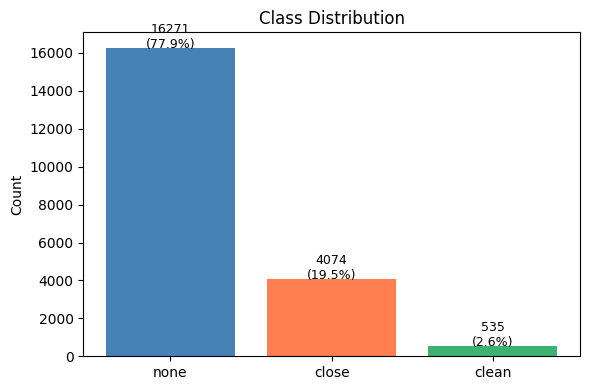

In [8]:
counts = df['action'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=['steelblue', 'coral', 'mediumseagreen'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=9)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/dataset/class_distribution.png', dpi=150)
plt.show()

## 2. Object Type Frequency — Labeled Only
Which objects most commonly require action?

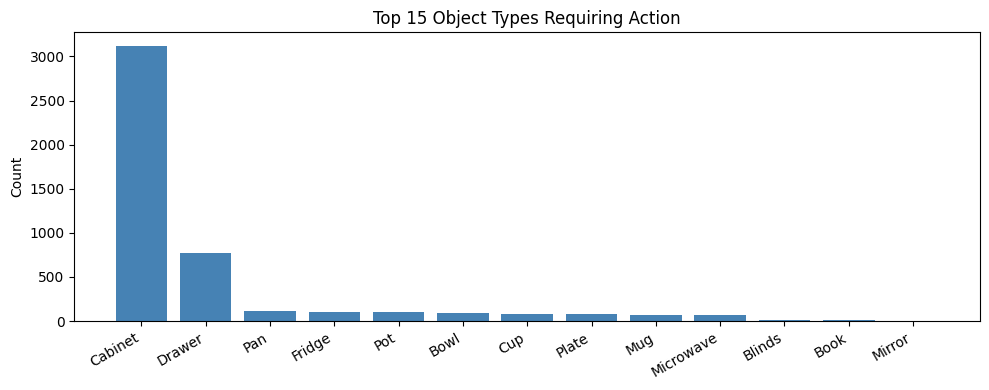

In [9]:
labeled = df[df['action'] != 'none']
obj_counts = labeled['object_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(obj_counts.index, obj_counts.values, color='steelblue')
ax.set_title('Top 15 Object Types Requiring Action')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/dataset/object_frequency.png', dpi=150)
plt.show()

## 3. Action per Object Type
For each object type, what actions are required?

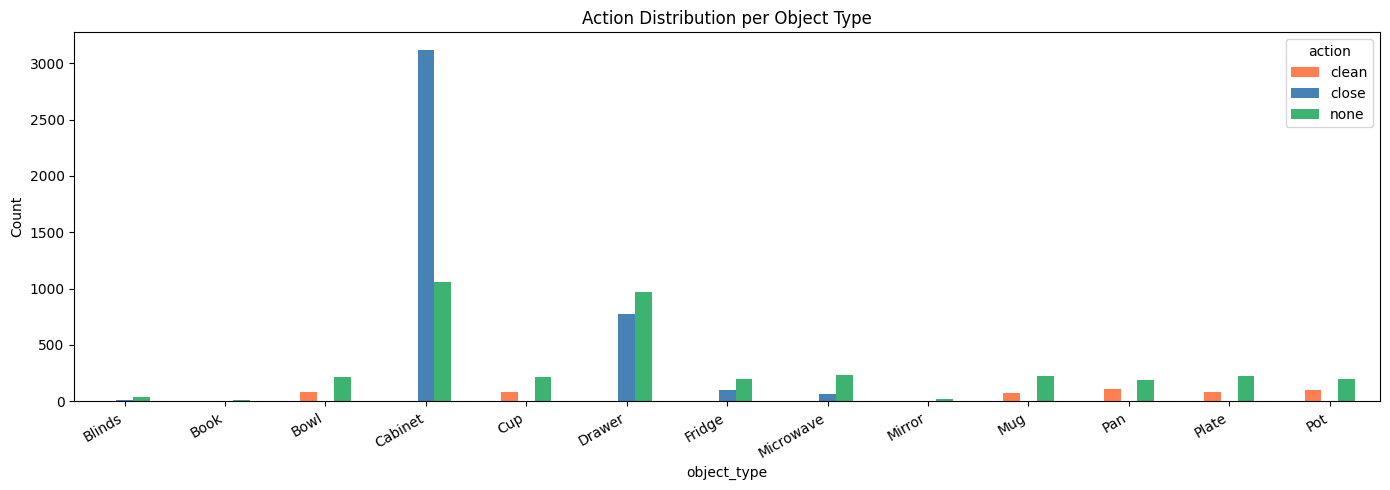

In [10]:
pivot = pd.crosstab(df['object_type'], df['action'])
pivot_labeled = pivot[pivot.index.isin(labeled['object_type'].unique())]

pivot_labeled.plot(kind='bar', figsize=(14, 5), 
                   color=['coral', 'steelblue', 'mediumseagreen'])
plt.title('Action Distribution per Object Type')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/dataset/action_per_object.png', dpi=150)
plt.show()

## 4. Feature Analysis
Distribution of state features (is_open, is_dirty, visible) across classes.

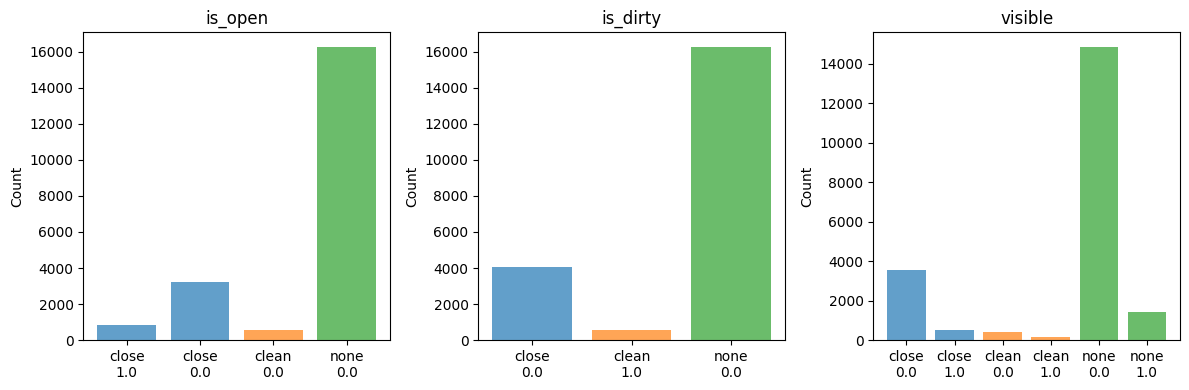

In [11]:
features = np.array([s['features'] for s in samples])
labels   = np.array([s['label']    for s in samples])

# last 3 features: is_open, is_dirty, visible
state_features = features[:, -3:]
feature_names  = ['is_open', 'is_dirty', 'visible']
action_names   = data['idx2action']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (fname, ax) in enumerate(zip(feature_names, axes)):
    for label_idx, action in action_names.items():
        mask = labels == int(label_idx)
        vals = state_features[mask, i]
        counts = Counter(vals)
        ax.bar([f"{action}\n{v}" for v in counts.keys()],
               counts.values(), alpha=0.7)
    ax.set_title(fname)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/dataset/feature_analysis.png', dpi=150)
plt.show()

## 5. Class Imbalance Summary

In [12]:
print("Class distribution:")
for action, count in df['action'].value_counts().items():
    print(f"  {action:<10} {count:>6} ({count/len(df)*100:.1f}%)")

print(f"\nImbalance ratio (none vs rest): "
      f"{len(df[df['action']=='none']) / len(df[df['action']!='none']):.1f}x")

print("\nRecommendation:")
if len(df[df['action']=='clean']) < 100:
    print("  - clean class too small. Increase DirtyObject probability.")
if len(df[df['action']=='close']) < len(df[df['action']=='none']) * 0.2:
    print("  - Consider class weighting or oversampling in D5 training.")

Class distribution:
  none        16271 (77.9%)
  close        4074 (19.5%)
  clean         535 (2.6%)

Imbalance ratio (none vs rest): 3.5x

Recommendation:


## Summary
- Class imbalance is expected — most objects require no action
- Will use class weighting in D5 model training to handle imbalance
- More episodes needed if clean class remains under-represented